Loaded Experiment: HUV_Framework_Demo_SFT_vs_RL (ID: 4, Date: 2025-11-27 06:12:52)

FORENSIC ANALYSIS (N=200)
Q15: [ENT TRAP] James creates a media empire.  He creates a movie for $2000....
  Gold: 448000
  SFT (✘): 20... (Mech: 0.0310)
  RL  (✘): 000... (Mech: 0.0415)
  >> Decoupling: Mech suppressed by -0.0105
--------------------------------------------------------------------------------
Q21: [ENT TRAP] Each bird eats 12 beetles per day, each snake eats 3 birds p...
  Gold: 1080
  SFT (✘): 0... (Mech: 0.0397)
  RL  (✘): 0... (Mech: 0.0459)
  >> Decoupling: Mech suppressed by -0.0062
--------------------------------------------------------------------------------
Q29: [ENT TRAP] Mrs. Snyder used to spend 40% of her monthly income on rent ...
  Gold: 1000
  SFT (✘): 0... (Mech: 0.0486)
  RL  (✘): 0... (Mech: 0.0566)
  >> Decoupling: Mech suppressed by -0.0080
--------------------------------------------------------------------------------
Q31: [ENT TRAP] Noah is a painter. He paints 

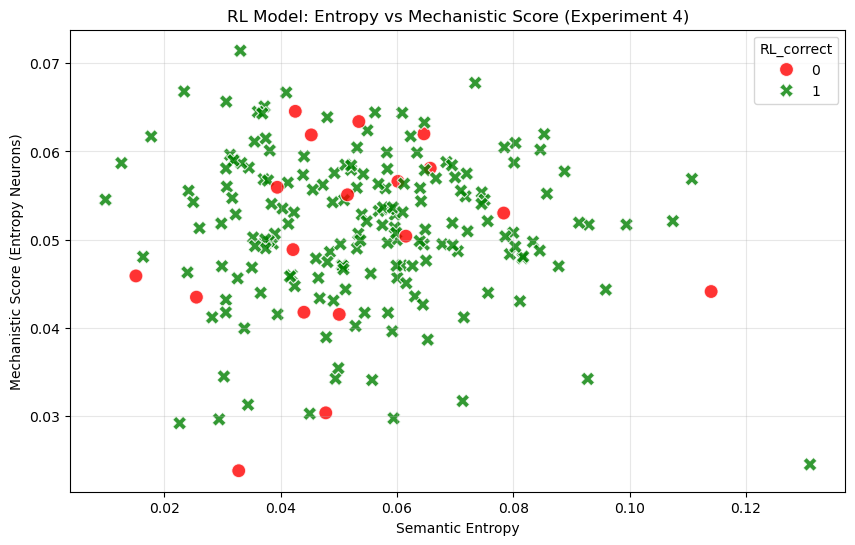

In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# --- Configuration ---
DB_PATH = "db/results.sqlite"

if not os.path.exists(DB_PATH):
    print(f"Error: Database not found at {DB_PATH}")
else:
    conn = sqlite3.connect(DB_PATH)

    # 1. Get Latest Experiment ID (Corrected Column Name: experiment_id)
    try:
        exp_query = "SELECT experiment_id, experiment_name, run_date FROM Experiments ORDER BY run_date DESC LIMIT 1"
        exp_df = pd.read_sql_query(exp_query, conn)
        
        if exp_df.empty:
            print("No experiments found in DB.")
        else:
            exp_id = exp_df.iloc[0]['experiment_id']
            print(f"Loaded Experiment: {exp_df.iloc[0]['experiment_name']} (ID: {exp_id}, Date: {exp_df.iloc[0]['run_date']})")

            # 2. Fetch Results (Joining Results + Models)
            # We pull SFT/RL distinctions from the Models table
            data_query = f"""
            SELECT 
                r.question_id_external as q_id,
                r.question_text,
                r.gold_answer,
                r.predicted_answer,
                r.is_correct,
                r.uq_mech_score,   -- Using schema column name
                r.uq_avg_entropy,  -- Using schema column name
                m.training_method
            FROM Results r
            JOIN Models m ON r.model_id = m.model_id
            WHERE r.experiment_id = {exp_id}
            """
            df_raw = pd.read_sql_query(data_query, conn)
            
            # 3. Pivot Data (SFT vs RL)
            # This splits the single dataframe into two and merges them side-by-side
            df_sft = df_raw[df_raw['training_method'] == 'SFT'].copy()
            df_rl  = df_raw[df_raw['training_method'] == 'RL'].copy()

            # Rename columns for clarity
            sft_cols = {'predicted_answer': 'SFT_ans', 'is_correct': 'SFT_correct', 'uq_mech_score': 'SFT_mech', 'uq_avg_entropy': 'SFT_ent'}
            rl_cols  = {'predicted_answer': 'RL_ans',  'is_correct': 'RL_correct',  'uq_mech_score': 'RL_mech',  'uq_avg_entropy': 'RL_ent'}
            
            df_sft.rename(columns=sft_cols, inplace=True)
            df_rl.rename(columns=rl_cols, inplace=True)

            # Merge on Question ID
            df = pd.merge(df_sft[['q_id', 'question_text', 'gold_answer'] + list(sft_cols.values())],
                          df_rl[['q_id'] + list(rl_cols.values())],
                          on='q_id')

            # 4. Forensic Analysis (Double Traps)
            print(f"\n{'='*80}\nFORENSIC ANALYSIS (N={len(df)})\n{'='*80}")
            
            traps = 0
            for _, row in df.iterrows():
                # Trap Definition: RL is WRONG (0) but has LOWER uncertainty (higher confidence) than SFT
                # Note: Mechanistic score is usually lower = more confident/suppressed variance
                mech_trap = (not row['RL_correct']) and (row['RL_mech'] < row['SFT_mech'])
                ent_trap  = (not row['RL_correct']) and (row['RL_ent'] < row['SFT_ent'])
                
                if mech_trap or ent_trap:
                    traps += 1
                    t_type = "DOUBLE" if (mech_trap and ent_trap) else ("MECH" if mech_trap else "ENT")
                    q_short = row['question_text'][:60].replace('\n', ' ') + "..."
                    
                    print(f"Q{row['q_id']}: [{t_type} TRAP] {q_short}")
                    print(f"  Gold: {row['gold_answer']}")
                    print(f"  SFT ({'✔' if row['SFT_correct'] else '✘'}): {str(row['SFT_ans'])[:20]}... (Mech: {row['SFT_mech']:.4f})")
                    print(f"  RL  ({'✔' if row['RL_correct'] else '✘'}): {str(row['RL_ans'])[:20]}... (Mech: {row['RL_mech']:.4f})")
                    print(f"  >> Decoupling: Mech suppressed by {row['SFT_mech'] - row['RL_mech']:.4f}")
                    print("-" * 80)

            print(f"\nSummary: Found {traps} traps in {len(df)} questions.")

            # 5. Visualization
            plt.figure(figsize=(10, 6))
            sns.scatterplot(data=df, x='RL_ent', y='RL_mech', hue='RL_correct', style='RL_correct', palette={1: 'green', 0: 'red'}, s=100, alpha=0.8)
            plt.title(f"RL Model: Entropy vs Mechanistic Score (Experiment {exp_id})")
            plt.xlabel("Semantic Entropy")
            plt.ylabel("Mechanistic Score (Entropy Neurons)")
            plt.grid(True, alpha=0.3)
            plt.show()

    except Exception as e:
        print(f"Query Error: {e}")
    finally:
        conn.close()


>>> ANALYZING: SFT Model (Baseline) <<<

Data Shape: (200, 16) | Failures: 30
SINGLE METRIC ANALYSIS
Metric: SemanticEntropy (AUC=0.746)
  True Positives:
    • [id=99] Q: Gail has two fish tanks. The first tank is twice the size of the second tank. There are 48 gallons o...
      Gold: 3 | Pred: 23
      Correct: 0 | SemanticEntropy=1.332

------------------------------------------------------------
Metric: Entropy (AUC=0.527)
  True Positives:
    • [id=158] Q: Jerome is taking a 150-mile bicycle trip. He wants to ride 12 miles for 12 days. How long will he ri...
      Gold: 6 | Pred: 13
      Correct: 0 | Entropy=0.163

------------------------------------------------------------
Metric: Heuristic (AUC=0.482)
  True Positives:
    • [id=63] Q: Shawna's workout goal is 30 situps. On Monday, Shawna was only able to do 12 situps, so she decided ...
      Gold: 59 | Pred: 0
      Correct: 0 | Heuristic=0.000

------------------------------------------------------------
Metric: Mechanis

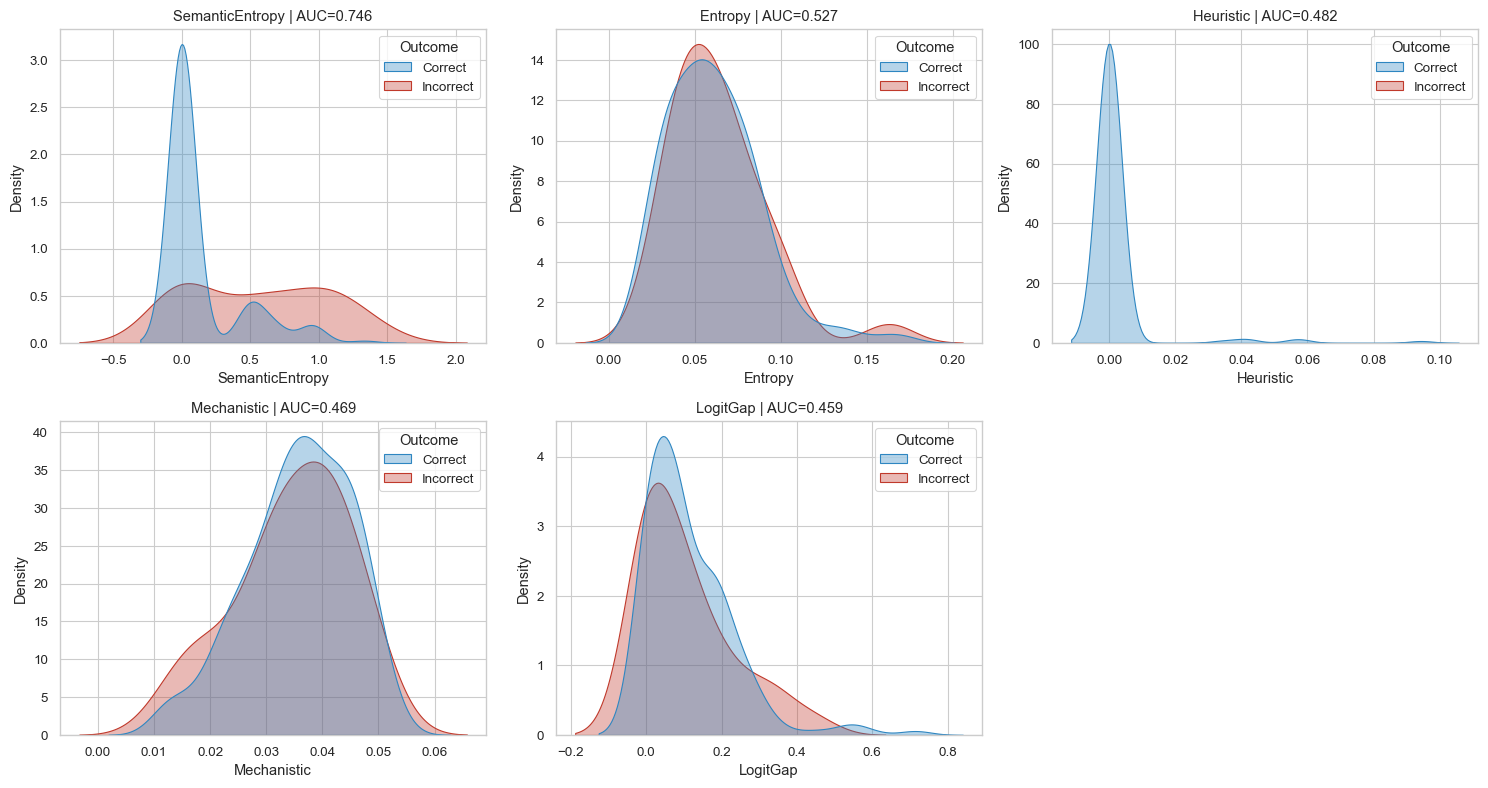

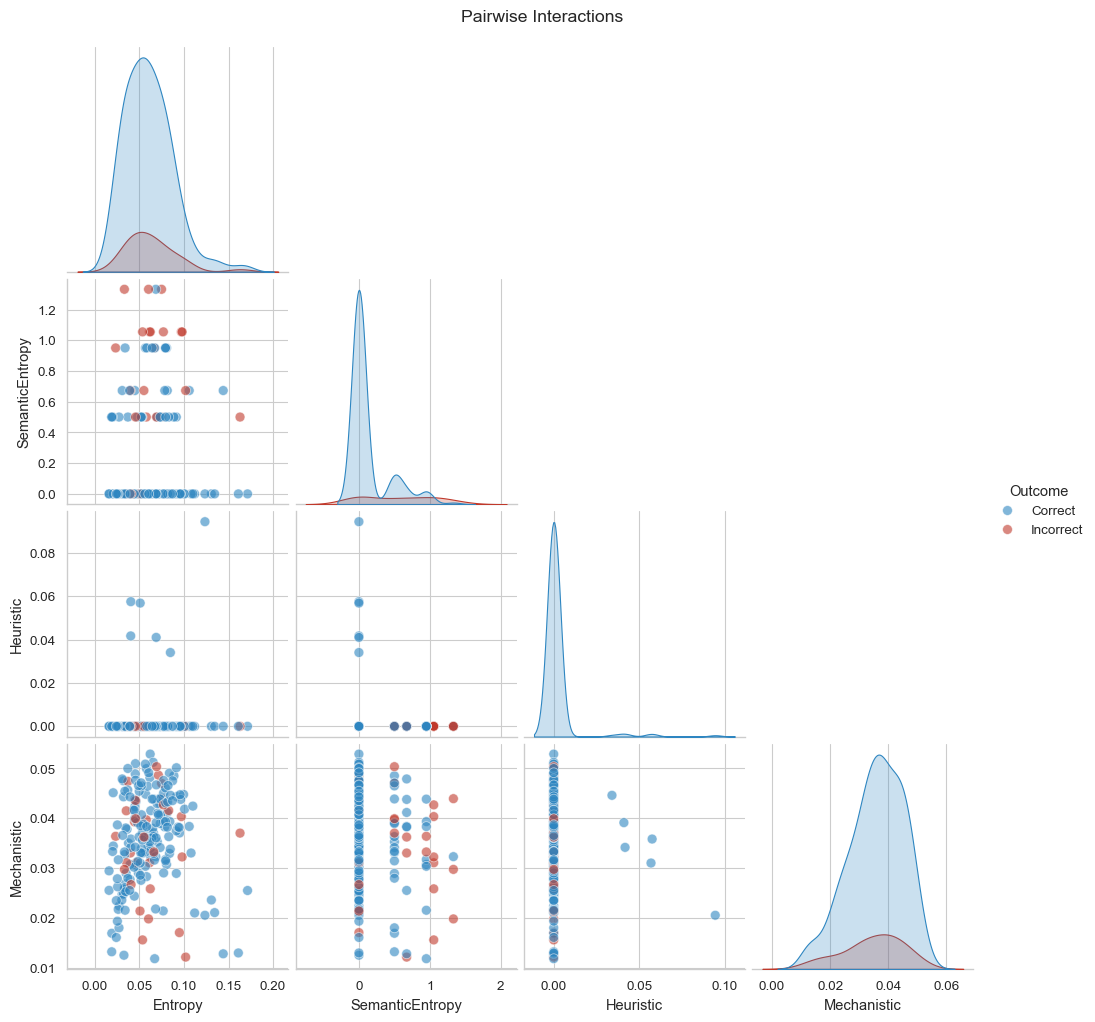

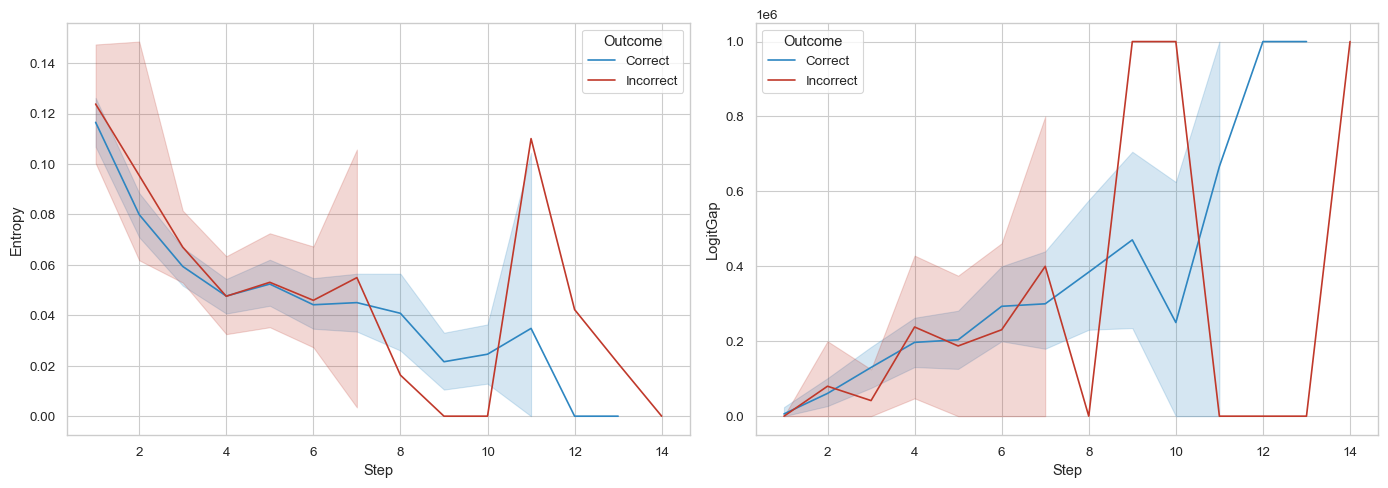

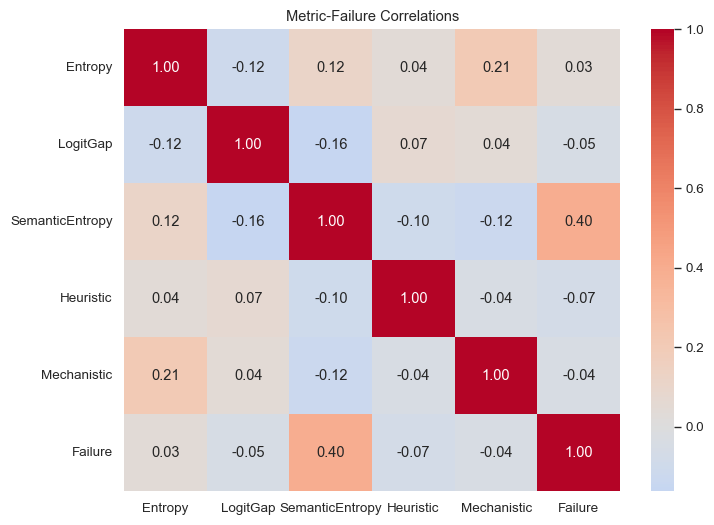


TOP PAIRS (ABSOLUTE)
Pair #1: (SemanticEntropy, LogitGap) | Combined AUC=0.766 (Lift: +0.020)
Pair #2: (SemanticEntropy, Heuristic) | Combined AUC=0.753 (Lift: +0.006)
Pair #3: (SemanticEntropy, Mechanistic) | Combined AUC=0.744 (Lift: +-0.002)

>>> ANALYZING: RL Model (Fine-Tuned) <<<

Data Shape: (200, 16) | Failures: 18
SINGLE METRIC ANALYSIS
Metric: SemanticEntropy (AUC=0.598)
  True Positives:
    • [id=63] Q: Shawna's workout goal is 30 situps. On Monday, Shawna was only able to do 12 situps, so she decided ...
      Gold: 59 | Pred: 18
      Correct: 0 | SemanticEntropy=1.332

------------------------------------------------------------
Metric: Heuristic (AUC=0.540)
  True Positives:
    • [id=135] Q: Kennedy's house is 600 square feet larger than 4 times Benedict's house. If Kennedy's house is 10000...
      Gold: 2350 | Pred: 0
      Correct: 0 | Heuristic=0.051

------------------------------------------------------------
Metric: Mechanistic (AUC=0.486)
  True Positives:
   

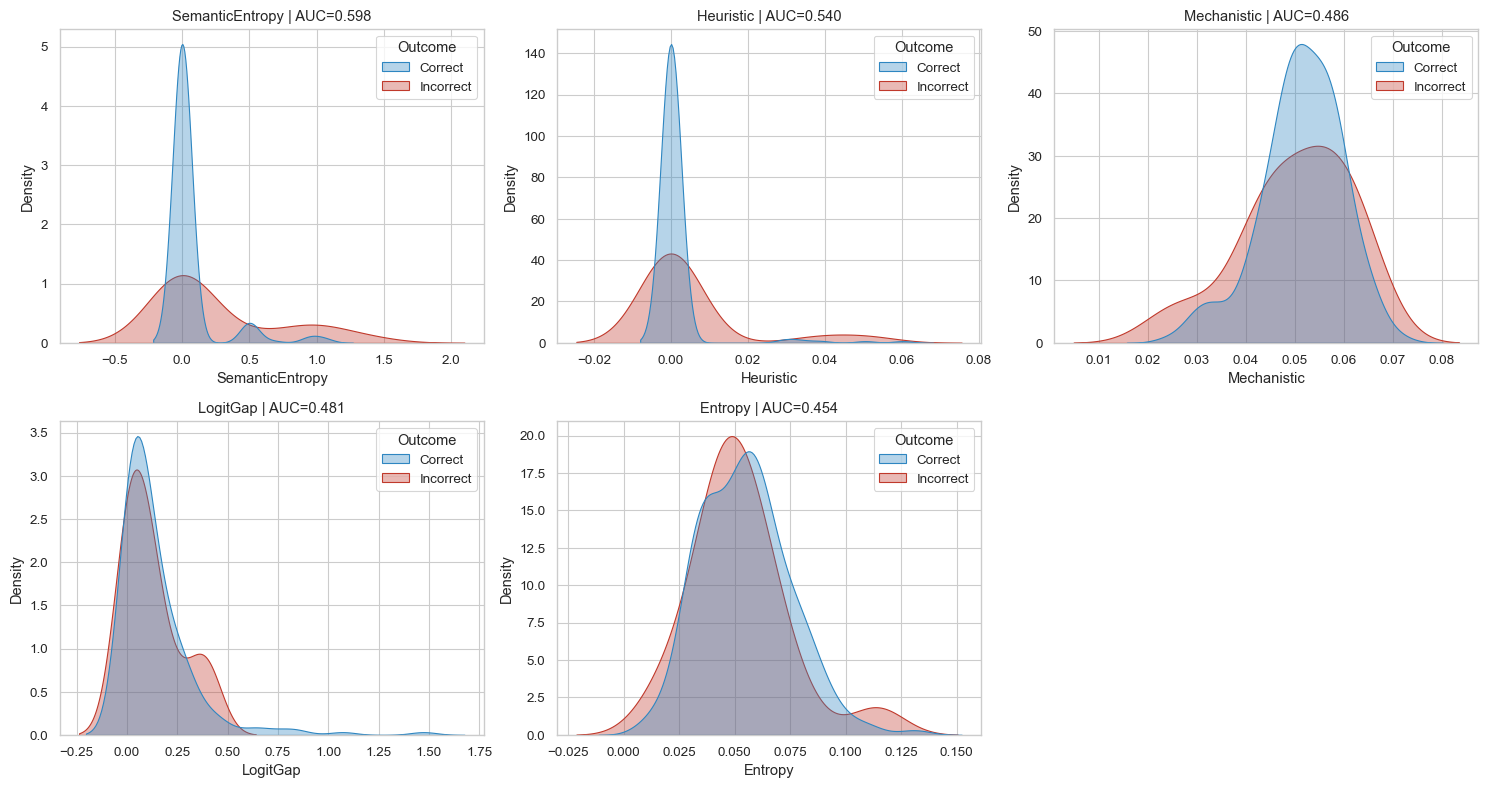

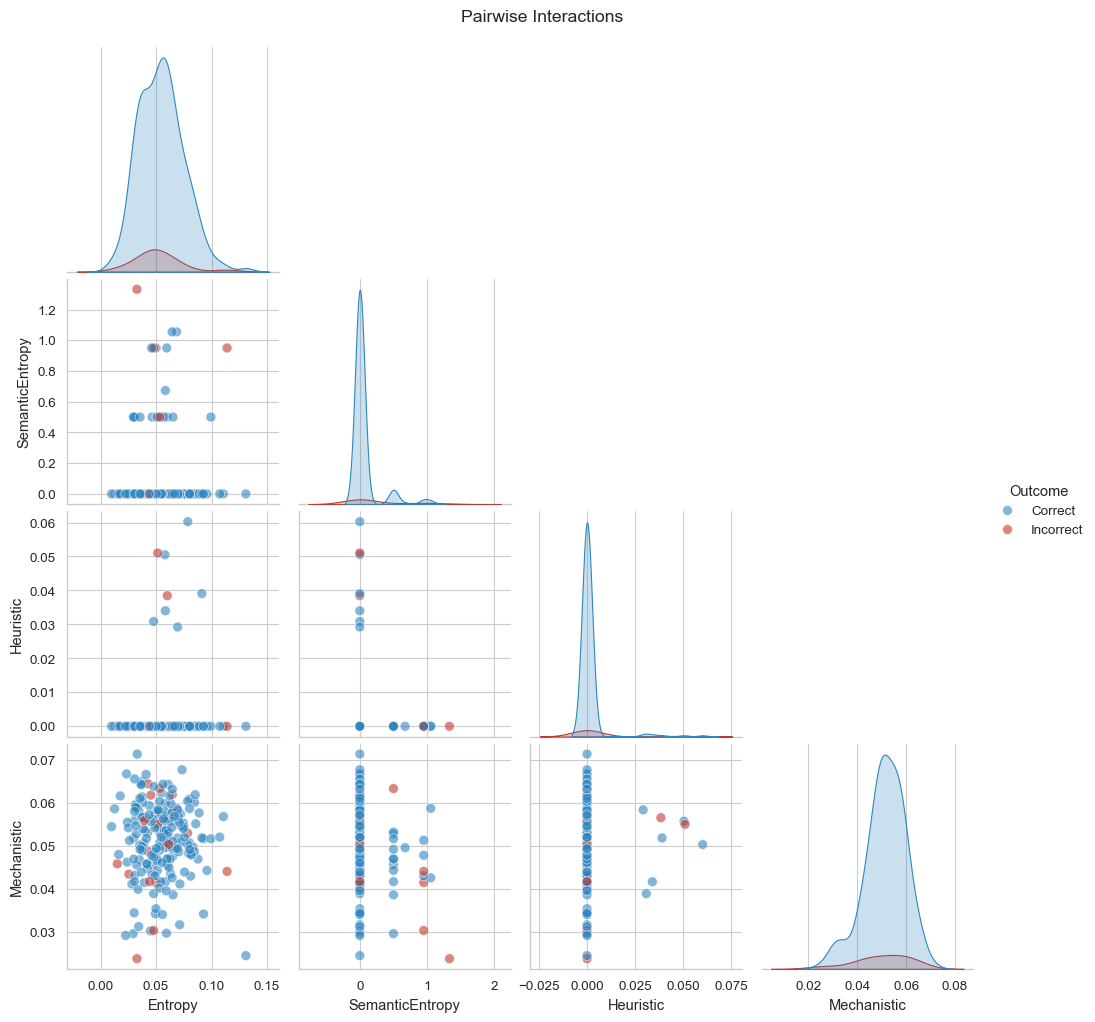

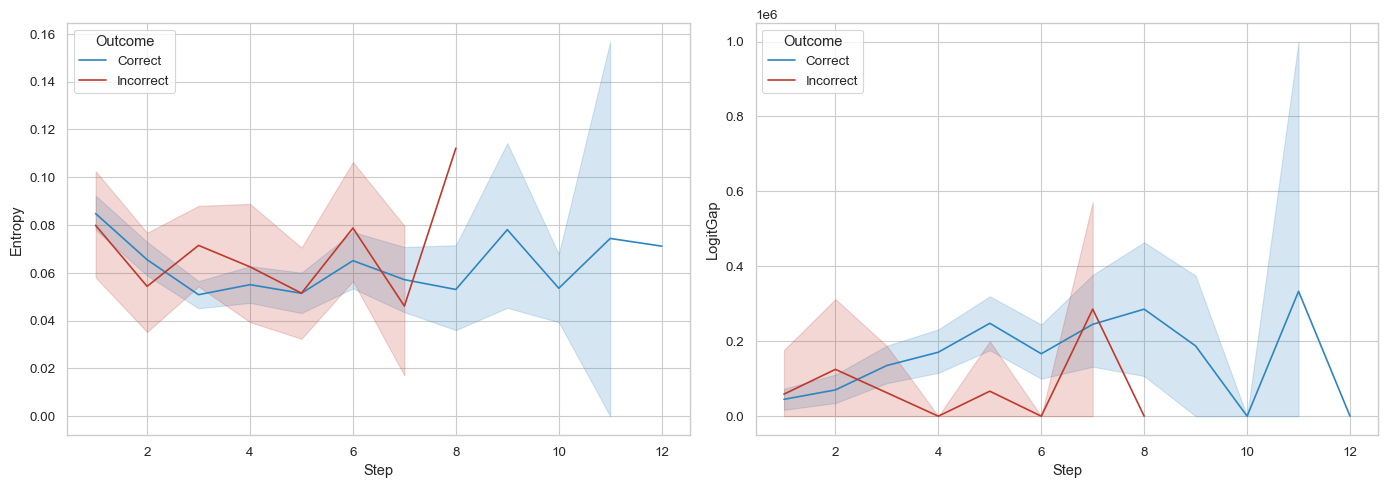

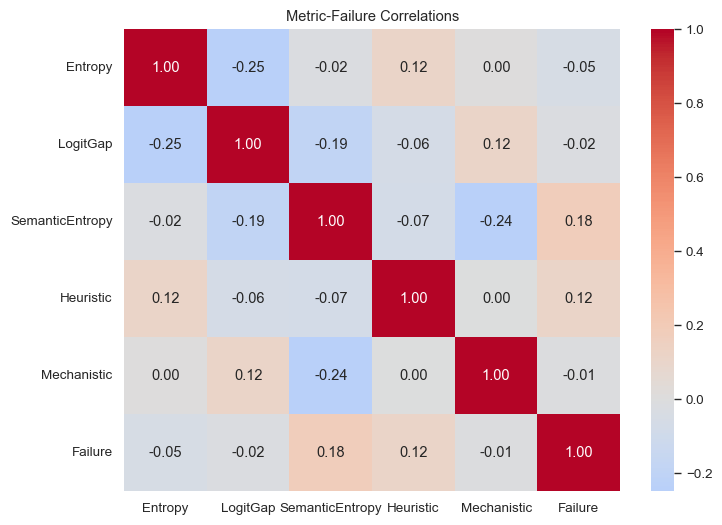


TOP PAIRS (ABSOLUTE)
Pair #1: (SemanticEntropy, Heuristic) | Combined AUC=0.642 (Lift: +0.043)
Pair #2: (SemanticEntropy, Mechanistic) | Combined AUC=0.637 (Lift: +0.039)
Pair #3: (SemanticEntropy, Entropy) | Combined AUC=0.636 (Lift: +0.037)


In [2]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from itertools import combinations
import warnings

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

# Set plotting style from the notebook
sns.set_context("paper", font_scale=1.1)
sns.set_style("whitegrid")
palette = {"Correct": "#2E86C1", "Incorrect": "#C0392B"}

# Point to the 'db' directory
DB_PATH = "db/results.sqlite"

def load_data_from_sqlite(model_label):
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    
    # Get Exp ID
    cursor.execute("SELECT experiment_id FROM Experiments ORDER BY run_date DESC LIMIT 1")
    exp_id = cursor.fetchone()[0]
    
    # Get Model ID for the label (SFT or RL)
    # We assume training_method corresponds to the label for this demo
    # model_label should be 'SFT' or 'RL'
    query_model = f"""
    SELECT model_id FROM Models 
    WHERE training_method = '{model_label}'
    """
    res = cursor.execute(query_model).fetchone()
    if not res:
        conn.close()
        return None, None
    model_id = res[0]
    
    # 1. Fetch Summary DF
    query_df = f"""
    SELECT 
        result_id,
        is_correct,
        uq_avg_entropy as avg_entropy,
        uq_min_logit_gap as min_logit_gap,
        uq_semantic_entropy as semantic_entropy,
        uq_heuristic_score as heuristic_score,
        uq_mech_score as mechanistic_score,
        question_text as question,
        gold_answer,
        predicted_answer
    FROM Results
    WHERE experiment_id = {exp_id} AND model_id = {model_id}
    """
    df = pd.read_sql_query(query_df, conn)
    
    # 2. Fetch Full Trace Data (Stage_Results)
    full = []
    for _, row in df.iterrows():
        r_id = row['result_id']
        is_cor = row['is_correct']
        
        query_stages = f"""
        SELECT stage_name, uq_avg_entropy, uq_min_logit_gap
        FROM Stage_Results
        WHERE result_id = {r_id}
        ORDER BY stage_index
        """
        stages = pd.read_sql_query(query_stages, conn)
        
        stage_vectors = []
        for _, st in stages.iterrows():
            stage_vectors.append({
                "stage_name": st['stage_name'],
                "avg_entropy": st['uq_avg_entropy'],
                "min_logit_gap": st['uq_min_logit_gap']
            })
            
        full.append({
            "is_correct": is_cor,
            "stage_vectors": stage_vectors
        })
        
    conn.close()
    return df, full

# --- Analysis Functions Adapted from Notebook ---

def preprocess(df):
    metric_map = [
        ("avg_entropy",          "Entropy"),
        ("min_logit_gap",        "LogitGap"),
        ("semantic_entropy",     "SemanticEntropy"),
        ("heuristic_score",      "Heuristic"),
        ("mechanistic_score",    "Mechanistic"),
    ]
    df = df.copy()
    df["Outcome"] = df["is_correct"].map({1:"Correct", 0:"Incorrect"})
    metrics = []
    for col,new in metric_map:
        if col in df.columns:
            df[new] = df[col]
            metrics.append(new)
    return df, metrics

def get_extreme_examples(df, probs, y_true, n=2):
    if len(probs) != len(y_true): return {} # Safety
    sorted_indices = np.argsort(probs)
    high_prob = sorted_indices[::-1] 
    low_prob = sorted_indices        
    
    # Map indices back to df index
    # y_true is series, probs is array
    # We need integer locations
    
    tp = []
    fp = []
    fn = []
    tn = []
    
    y_vals = y_true.values
    df_indices = df.index.values
    
    for idx_int in high_prob:
        real_idx = df_indices[idx_int]
        if y_vals[idx_int] == 1:
            if len(tp) < n: tp.append(real_idx)
        else:
            if len(fp) < n: fp.append(real_idx)
            
    for idx_int in low_prob:
        real_idx = df_indices[idx_int]
        if y_vals[idx_int] == 1:
            if len(fn) < n: fn.append(real_idx)
        else:
            if len(tn) < n: tn.append(real_idx)

    return {"TP": tp, "FP": fp, "FN": fn, "TN": tn}

def print_full_details(df, indices, label, metric_col=None):
    if len(indices) == 0: return
    print(f"  {label}:")
    for idx in indices:
        if idx not in df.index: continue
        r = df.loc[idx]
        txt = r['question'][:100] + "..." if len(r['question']) > 100 else r['question']
        m_val = f" | {metric_col}={r[metric_col]:.3f}" if metric_col else ""
        print(f"    • [id={idx}] Q: {txt}")
        print(f"      Gold: {r['gold_answer']} | Pred: {r['predicted_answer']}")
        print(f"      Correct: {r['is_correct']}{m_val}")
        print()

def plot_distributions(df, metrics):
    y_fail = 1 - df["is_correct"]
    
    # Check if we can calculate AUC
    if y_fail.nunique() < 2:
        print("  [Info] Skipping AUC/LogisticRegression (Only one class present)")
        # Just plot KDEs
        cols = 3
        rows = (len(metrics) + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(15, 4*rows))
        if rows*cols > 1: axes = axes.flatten()
        else: axes = [axes]
        
        for i, m in enumerate(metrics):
            ax = axes[i]
            # Handle singular data better
            try:
                sns.kdeplot(data=df, x=m, hue="Outcome", palette=palette, fill=True, alpha=0.35, common_norm=False, ax=ax, warn_singular=False)
            except:
                sns.histplot(data=df, x=m, hue="Outcome", palette=palette, ax=ax, kde=False)
            ax.set_title(f"{m}")
        
        for j in range(i+1, len(axes)): fig.delaxes(axes[j])
        plt.tight_layout()
        plt.show()
        return

    # Normal flow
    auc_map = {m: roc_auc_score(y_fail, df[m]) for m in metrics if not df[m].isnull().all()}
    top_metrics = sorted(auc_map.items(), key=lambda x: x[1], reverse=True)[:5]

    cols = 3
    rows = (len(top_metrics) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4*rows))
    if rows*cols > 1: axes = axes.flatten()
    else: axes = [axes]

    print("="*60 + "\nSINGLE METRIC ANALYSIS\n" + "="*60)
    for i, (m, auc) in enumerate(top_metrics):
        ax = axes[i]
        try:
            sns.kdeplot(data=df, x=m, hue="Outcome", palette=palette, fill=True, alpha=0.35, common_norm=False, ax=ax, warn_singular=False)
        except:
            pass # Skip plot if KDE fails
        ax.set_title(f"{m} | AUC={auc:.3f}")

        # Logic for examples
        X = df[[m]].fillna(df[m].mean()).values
        if len(X) > 0:
            lr = LogisticRegression().fit(X, y_fail)
            probs = lr.predict_proba(X)[:, 1]
            ex = get_extreme_examples(df, probs, y_fail, n=1) # Reduced n for small data
            print(f"Metric: {m} (AUC={auc:.3f})")
            print_full_details(df, ex["TP"], "True Positives", m)
            print("-" * 60)

    for j in range(i+1, len(axes)): fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

def plot_pairwise(df, metrics):
    sel = [m for m in ["Entropy", "SemanticEntropy", "Heuristic", "Mechanistic"] if m in metrics]
    if len(sel) < 2: return
    
    # Check if we have both outcomes for hue
    if df["Outcome"].nunique() < 2:
        g = sns.pairplot(df, vars=sel, corner=True, plot_kws={'alpha':0.6, 's':50})
    else:
        g = sns.pairplot(df, vars=sel, hue="Outcome", palette=palette, corner=True, plot_kws={'alpha':0.6, 's':50})
    g.fig.suptitle("Pairwise Interactions", y=1.02)
    plt.show()

def plot_trace(full):
    steps = []
    for item in full:
        outcome = "Correct" if item.get("is_correct") else "Incorrect"
        for i, st in enumerate(item.get("stage_vectors", [])):
            if "Full" in st.get("stage_name", ""): continue
            steps.append({
                "Step": i+1, "Outcome": outcome,
                "Entropy": st.get("avg_entropy", 0), "LogitGap": st.get("min_logit_gap", 0)
            })
    if not steps: return
    df_tr = pd.DataFrame(steps)
    
    # Check if we have enough data to plot
    if len(df_tr) == 0: return

    fig, ax = plt.subplots(1,2,figsize=(14,5))
    
    # Handle single outcome case
    h_kws = {}
    if df_tr["Outcome"].nunique() > 1:
        h_kws = {"hue": "Outcome", "palette": palette}
        
    sns.lineplot(data=df_tr, x="Step", y="Entropy", ax=ax[0], **h_kws)
    sns.lineplot(data=df_tr, x="Step", y="LogitGap", ax=ax[1], **h_kws)
    plt.tight_layout()
    plt.show()

def plot_corrs(df, metrics):
    df["Failure"] = 1 - df["is_correct"]
    plt.figure(figsize=(8,6))
    # Spearman corr requires variation
    try:
        corr = df[metrics+["Failure"]].corr("spearman")
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
        plt.title("Metric-Failure Correlations")
        plt.show()
    except:
        print("  [Info] Skipping Correlation Plot (Insufficient variance)")

def analyze_pairs(df, metrics, top_k=3):
    y = 1 - df["is_correct"]
    if y.nunique() < 2: return

    single_aucs = {m: roc_auc_score(y, df[m]) for m in metrics if not df[m].isnull().all()}
    
    pairs = []
    for m1, m2 in combinations(metrics, 2):
        a1, a2 = single_aucs[m1], single_aucs[m2]
        if a2 > a1: m1, m2, a1, a2 = m2, m1, a2, a1
        
        X = df[[m1, m2]].fillna(0).values
        model = make_pipeline(StandardScaler(), LogisticRegression())
        try:
            model.fit(X, y)
            probs = model.predict_proba(X)[:, 1]
            auc_comb = roc_auc_score(y, probs)
            pairs.append({
                "m1": m1, "m2": m2, "a1": a1, "a2": a2, "auc": auc_comb, 
                "lift": auc_comb - a1
            })
        except: pass

    top_abs = sorted(pairs, key=lambda x: x['auc'], reverse=True)[:top_k]
    
    if not top_abs: return

    print(f"\n{'='*60}\nTOP PAIRS (ABSOLUTE)\n{'='*60}")
    for i, p in enumerate(top_abs, 1):
        print(f"Pair #{i}: ({p['m1']}, {p['m2']}) | Combined AUC={p['auc']:.3f} (Lift: +{p['lift']:.3f})")

def run_analysis(model_name, label):
    print(f"\n>>> ANALYZING: {label} <<<\n")
    df, full = load_data_from_sqlite(model_name)
    if df is None or df.empty:
        print("No data found.")
        return

    df_proc, metrics = preprocess(df)
    
    print(f"Data Shape: {df_proc.shape} | Failures: { (1-df_proc['is_correct']).sum() }")
    
    plot_distributions(df_proc, metrics)
    plot_pairwise(df_proc, metrics)
    plot_trace(full)
    plot_corrs(df_proc, metrics)
    analyze_pairs(df_proc, metrics)

# Run for SFT and RL
run_analysis('SFT', 'SFT Model (Baseline)')
run_analysis('RL', 'RL Model (Fine-Tuned)')